<h1 style="color:#6c63ff; font-weight:bold;">Gym Data Modeling</p>

<h2 style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">Index</h2>


<style>
a { color: #6c63ff !important; }
</style>

<div style="padding: 10px 0; color:#6c63ff;">

**6. Imports**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.1 Libraries Imports](#imports)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[6.2 Gym Data Importation](#gym-data)


**7. Clustering**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.1 Elbow ](#elbow)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.2 Silhouette ](#silhouette)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.3 K-Means ](#kmeans)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.4 Hierarchical Clustering ](#hclustering)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.5 Self Organizing Map](#som)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[7.6 Comparing Algorithms ](#comparing-algorithms)

**8. Cluster Analysis**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.1 Cluster Creation ](#clucreation)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[8.2 Cluster Visualization](#cluview)

**9. Conclusions**
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.1 Summary of Findings ](#fisuma)
<br>&nbsp;&nbsp;&nbsp;&nbsp;[9.2 Business Recommendations](#bureco)


</div>

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">6. Imports</h2>

<h3 style="color:#6c63ff; padding-bottom:5px;">Libraries Imports</h3>

In [306]:
!pip install minisom

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from minisom import MiniSom

<h3 style="color:#6c63ff; padding-bottom:5px;">Gym Data Importation</h3>

In [308]:
data = pd.read_csv('cleaned_gym_membership.csv')

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">7. Clustering</h2>

In [309]:
num_variables = ["Age", "visit_per_week", "avg_day", "day_sin", "day_cos", "ratio_cardio", "ratio_strength", "ratio_mind_body", "total_minutes", "avg_time_in_gym", "num_classes_attended","Berry Boost", "Lemon", "Passion Fruit", "Coconut Pineapple", "Orange", "Black Currant"]
cat_variables = ['gender', 'abonoment_type', 'name_personal_trainer', 'uses_sauna']

In [310]:
data_cluster = data.drop(cat_variables, axis=1)

<h3 id = "elbow"style="color:#6c63ff; padding-bottom:5px;"> Elbow</h3>

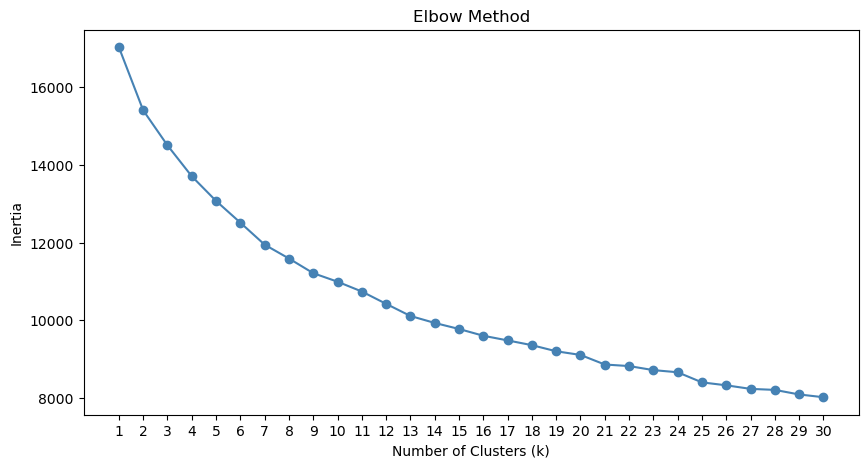

In [311]:
inertias = []
k_range = range(1, 31)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_cluster)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

<h3 id = "silhouette" style="color:#6c63ff; padding-bottom:5px;"> Silhouette</h3>

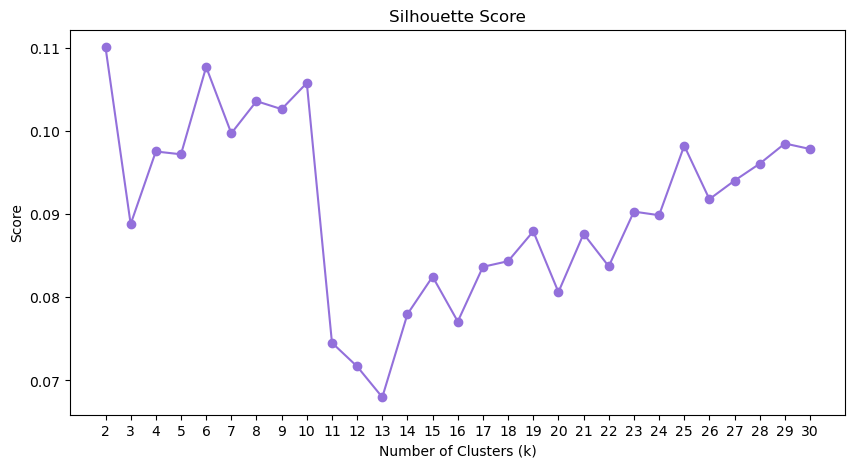

In [312]:
silhouettes = []
k_range = range(2, 31)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_cluster)
    silhouettes.append(silhouette_score(data_cluster, labels))
    
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouettes, marker='o', color='mediumpurple')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.xticks(k_range)
plt.show()

<h3 id = "kmeans" style="color:#6c63ff; padding-bottom:5px;"> K-Means</h3>

In [313]:
k_values = [2, 5, 6, 7, 8]

best_k_k_means = None
best_silhouette_k_means = 0

k_means = pd.DataFrame()

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    k_means = kmeans.fit_predict(data_cluster)
    score = silhouette_score(data_cluster, k_means)
    print(f'k={k} | Silhouette Score: {score:.4f}')
    if score > best_silhouette_k_means:
        best_k_k_means = k
        best_silhouette_k_means = score
print(f'Best k={best_k_k_means} | Best Silhouette Score: {best_silhouette_k_means:.4f}')

k=2 | Silhouette Score: 0.1101
k=5 | Silhouette Score: 0.0972
k=6 | Silhouette Score: 0.1077
k=7 | Silhouette Score: 0.0997
k=8 | Silhouette Score: 0.1036
Best k=2 | Best Silhouette Score: 0.1101


<h3 id = "hclustering" style="color:#6c63ff; padding-bottom:5px;"> Hierarchical Clustering</h3>

In [314]:
k_values = [2, 5, 6, 7, 8]
linkages = ['ward', 'complete', 'average', 'single']

best_k_hc = None
best_silhouette_hc = 0

for linkage in linkages:
    print(f'\n--- {linkage.upper()} Linkage ---')
    best_k = None
    best_sil = 0
    for k in k_values:
        hc = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = hc.fit_predict(data_cluster)
        score = silhouette_score(data_cluster, labels)
        print(f'k={k} | Silhouette Score: {score:.4f}')
        if score > best_sil:
            best_k = k
            best_sil = score
    print(f'Best k={best_k} | Best Silhouette Score: {best_sil:.4f}')
    if best_sil > best_silhouette_hc:
        best_k_hc = (linkage, best_k)
        best_silhouette_hc = best_sil
print()
print(f'Best overall k={best_k_hc[1]} with {best_k_hc[0].upper()} linkage | Best Silhouette Score: {best_silhouette_hc:.4f}')


--- WARD Linkage ---
k=2 | Silhouette Score: 0.1288
k=5 | Silhouette Score: 0.0435
k=6 | Silhouette Score: 0.0534
k=7 | Silhouette Score: 0.0685
k=8 | Silhouette Score: 0.0776
Best k=2 | Best Silhouette Score: 0.1288

--- COMPLETE Linkage ---
k=2 | Silhouette Score: 0.0858
k=5 | Silhouette Score: 0.0743
k=6 | Silhouette Score: 0.0726
k=7 | Silhouette Score: 0.0541
k=8 | Silhouette Score: 0.0668
Best k=2 | Best Silhouette Score: 0.0858

--- AVERAGE Linkage ---
k=2 | Silhouette Score: 0.2044
k=5 | Silhouette Score: 0.1084
k=6 | Silhouette Score: 0.0898
k=7 | Silhouette Score: 0.0842
k=8 | Silhouette Score: 0.0797
Best k=2 | Best Silhouette Score: 0.2044

--- SINGLE Linkage ---
k=2 | Silhouette Score: 0.2587
k=5 | Silhouette Score: 0.1066
k=6 | Silhouette Score: 0.0930
k=7 | Silhouette Score: 0.0829
k=8 | Silhouette Score: 0.0648
Best k=2 | Best Silhouette Score: 0.2587

Best overall k=2 with SINGLE linkage | Best Silhouette Score: 0.2587


<h3 id = "som" style="color:#6c63ff; padding-bottom:5px;"> Self Organizing Maps</h3>

In [315]:
k_values = [2, 5, 6, 7, 8]

# Convert to numpy array first
data_array = data_cluster.values if hasattr(data_cluster, 'values') else data_cluster

print('--- SOM ---')
best_k_som = None
best_sil_som = 0
for k in k_values:
    som = MiniSom(x=k, y=1, input_len=data_array.shape[1], random_seed=42)
    som.train(data_array, num_iteration=1000)
    
    labels = np.array([som.winner(x)[0] for x in data_array])
    score = silhouette_score(data_array, labels)
    print(f'k={k} | Silhouette Score: {score:.4f}')
    if score > best_sil_som:
        best_k_som = k
        best_sil_som = score
print()
print(f'Best k={best_k_som} | Best Silhouette Score: {best_sil_som:.4f}')

--- SOM ---
k=2 | Silhouette Score: 0.0891
k=5 | Silhouette Score: 0.1034
k=6 | Silhouette Score: 0.0982
k=7 | Silhouette Score: 0.0928
k=8 | Silhouette Score: 0.0976

Best k=5 | Best Silhouette Score: 0.1034


<h3 id = "comparing-algorithms" style="color:#6c63ff; padding-bottom:5px;"> Comparing Algorithms</h3>

In [316]:
print("\n --- Summary ---")
print()
print(f'Best K-Means: k={best_k_k_means} | Silhouette Score: {best_silhouette_k_means:.4f}')
print(f'Best Hierarchical Clustering: k={best_k_hc[1]} | Silhouette Score: {best_silhouette_hc:.4f}')
print(f'Best SOM: k={best_k_som} | Silhouette Score: {best_sil_som:.4f}')


 --- Summary ---

Best K-Means: k=2 | Silhouette Score: 0.1101
Best Hierarchical Clustering: k=2 | Silhouette Score: 0.2587
Best SOM: k=5 | Silhouette Score: 0.1034


<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">Comparing the best results across all three models, we can conclude that the best performing model is Hierarchical Clustering with Single linkage and k=2, achieving the highest silhouette score of 0.2587. Therefore, this configuration will be used for the final cluster analysis.</p>

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">8. Cluster Analysis </h2>

<h3 id = "clucreation" style="color:#6c63ff; padding-bottom:5px;"> Clusters creation</h3>

<p style="color:#6c63ff; font-size:15px;"> Hierarchical Clustering </p>

In [317]:
model = AgglomerativeClustering(n_clusters=2, linkage='complete')
data['hc_clusters'] = model.fit_predict(data_cluster)

In [318]:
kmeans_final = KMeans(n_clusters=2, random_state=42)
data['k_means_clusters'] = kmeans_final.fit_predict(data_cluster)

In [319]:
data_array = data_cluster.values if hasattr(data_cluster, 'values') else data_cluster

som = MiniSom(x=5, y=1, input_len=data_array.shape[1], random_seed=42)
som.train(data_array, num_iteration=1000)

labels = np.array([som.winner(x)[0] for x in data_array])
data['som_clusters'] = labels

<p style="color:#6c63ff; font-weight:bold; font-size:15px;"> Data Head </p>

In [320]:
data.head()

,gender,Age,abonoment_type,visit_per_week,avg_time_in_gym,name_personal_trainer,uses_sauna,avg_day,day_sin,day_cos,...,Berry Boost,Lemon,Passion Fruit,Coconut Pineapple,Orange,Black Currant,personal_trainer_frequency,hc_clusters,k_means_clusters,som_clusters
0,Female,-0.333316,Premium,1.061773,0.246696,No one,True,-0.821214,1.226399,0.446476,...,-0.358703,-0.360477,-0.367524,-0.393363,-0.37969,-0.353354,0.482,1,1,0
1,Female,1.516386,Standard,0.256179,-1.315252,Chantal,False,-0.562438,1.053808,-0.035503,...,-0.358703,-0.360477,-0.367524,-0.393363,-0.37969,-0.353354,0.153,1,0,4
2,Male,0.961476,Premium,-1.355009,0.407485,Mike,False,1.507774,-1.863759,0.446476,...,2.787818,2.774104,-0.367524,-0.393363,-0.37969,-0.353354,0.140,1,1,1
3,Male,1.238931,Premium,0.256179,-0.143791,Mike,True,-0.303661,0.759267,-0.440312,...,-0.358703,-0.360477,2.720912,-0.393363,-0.37969,-0.353354,0.140,0,0,2
4,Male,1.238931,Standard,-0.549415,-1.269312,Mike,False,-0.433050,0.920377,-0.250004,...,-0.358703,-0.360477,-0.367524,-0.393363,-0.37969,-0.353354,0.140,1,1,1


<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Means of the clusters variables</p>

<p style="color:#6c63ff; font-size:15px;"> Hierarchical Clustering </p>

In [321]:
data.groupby('hc_clusters').mean(numeric_only=True)

,Age,visit_per_week,avg_time_in_gym,uses_sauna,avg_day,day_sin,day_cos,num_classes_attended,ratio_cardio,ratio_strength,...,total_minutes,Berry Boost,Lemon,Passion Fruit,Coconut Pineapple,Orange,Black Currant,personal_trainer_frequency,k_means_clusters,som_clusters
hc_clusters,,,,,,,,,,,,,,,,,,,,,
0,0.051186,-0.463714,-0.004311,0.514894,0.196934,-0.365906,0.627221,-0.102266,0.071530,-0.061573,...,-0.050896,0.190264,-0.067027,1.038700,-0.043596,-0.033468,-0.163707,0.310268,0.472340,2.225532
1,-0.015724,0.142448,0.001324,0.486275,-0.060496,0.112403,-0.192676,0.031415,-0.021973,0.018915,...,0.015635,-0.058447,0.020590,-0.319078,0.013392,0.010281,0.050289,0.297695,0.487582,2.375163


<p style="color:#6c63ff; font-size:15px;"> K-Means </p>

In [322]:
data.groupby('k_means_clusters').mean(numeric_only=True)

,Age,visit_per_week,avg_time_in_gym,uses_sauna,avg_day,day_sin,day_cos,num_classes_attended,ratio_cardio,ratio_strength,...,total_minutes,Berry Boost,Lemon,Passion Fruit,Coconut Pineapple,Orange,Black Currant,personal_trainer_frequency,hc_clusters,som_clusters
k_means_clusters,,,,,,,,,,,,,,,,,,,,,
0,0.002749,-0.013914,-0.013896,0.474806,0.032773,-0.015415,0.001733,-0.838101,-0.559862,-0.510558,...,-0.025811,-0.005025,-0.044589,-0.002418,0.039004,-0.035133,-0.032549,0.298810,0.759690,3.370155
1,-0.002930,0.014834,0.014815,0.512397,-0.034940,0.016434,-0.001848,0.893512,0.596878,0.544314,...,0.027517,0.005357,0.047537,0.002578,-0.041583,0.037456,0.034701,0.302612,0.770661,1.241736


<p style="color:#6c63ff; font-size:15px;"> Self Organizing Map </p>

In [323]:
data.groupby('som_clusters').mean(numeric_only=True)

,Age,visit_per_week,avg_time_in_gym,uses_sauna,avg_day,day_sin,day_cos,num_classes_attended,ratio_cardio,ratio_strength,...,total_minutes,Berry Boost,Lemon,Passion Fruit,Coconut Pineapple,Orange,Black Currant,personal_trainer_frequency,hc_clusters,k_means_clusters
som_clusters,,,,,,,,,,,,,,,,,,,,,
0,-0.215956,-0.382740,0.001632,0.517241,-0.702802,0.303830,0.720958,0.601614,-0.133808,1.381370,...,0.193454,-0.315303,-0.187534,-0.346224,-0.049196,-0.109522,-0.155766,0.331979,0.841379,0.875862
1,-0.010888,0.085583,0.020511,0.509804,0.328565,-0.307135,-0.188347,0.844426,0.900224,0.002057,...,-0.186323,-0.321686,0.598336,-0.294855,-0.140100,-0.013354,0.170966,0.297263,0.866667,0.894118
2,0.007832,-0.009819,-0.116054,0.500000,0.009434,-0.026513,-0.039683,-0.043519,-0.029088,0.014787,...,0.139991,-0.180598,-0.153476,2.720912,0.077432,0.046736,-0.083068,0.316896,0.103774,0.452830
3,0.179392,-0.041031,0.129840,0.407767,-0.194372,0.180367,0.127785,-0.069976,-0.013629,-0.095114,...,-0.065066,2.787818,-0.086581,-0.187615,-0.051358,0.293208,-0.013383,0.299320,0.679612,0.456311
4,0.037807,0.099593,-0.016723,0.493606,0.094994,0.047306,-0.167432,-0.743586,-0.526005,-0.492568,...,0.028962,-0.358703,-0.256258,-0.367524,0.102151,-0.040585,-0.027690,0.287187,0.872123,0.086957


<p style="color:#6c63ff; font-weight:bold; font-size:15px;">Observations by cluster</p>

<p style="color:#6c63ff; font-size:15px;"> Hierarchical Clustering </p>

In [324]:
data['hc_clusters'].value_counts().sort_index()

hc_clusters
0    235
1    765
Name: count, dtype: int64

<p style="color:#6c63ff; font-size:15px;"> K-Means </p>

In [325]:
data['k_means_clusters'].value_counts().sort_index()

k_means_clusters
0    516
1    484
Name: count, dtype: int64

<p style="color:#6c63ff; font-size:15px;"> Self Organizing Map </p>

In [326]:
data['som_clusters'].value_counts().sort_index()

som_clusters
0    145
1    255
2    106
3    103
4    391
Name: count, dtype: int64

<h3 id = "cluview" style="color:#6c63ff; padding-bottom:5px;"> Clusters Visualisation</h3>

<p style="color:#6c63ff; font-size:15px;"> Hierarchical Clustering </p>

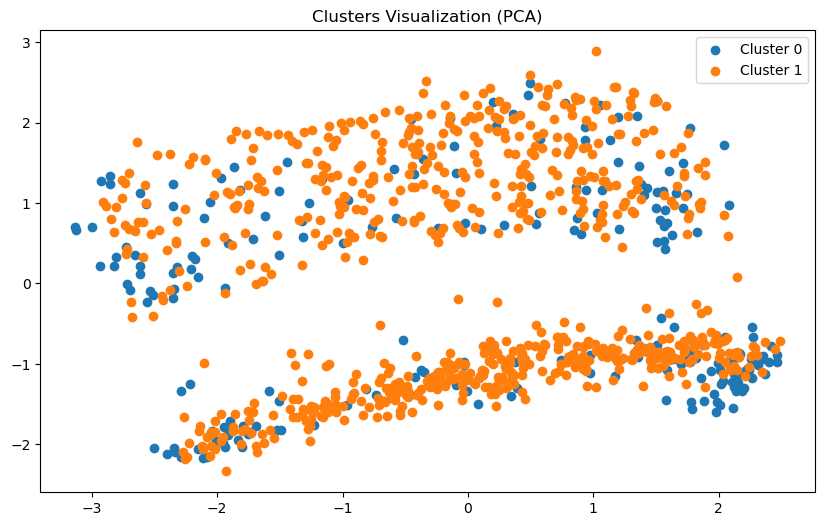

In [327]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_cluster)

plt.figure(figsize=(10, 6))
for cluster in range(2):
    mask = data['hc_clusters'] == cluster
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1], label=f'Cluster {cluster}')
plt.title('Clusters Visualization (PCA)')
plt.legend()
plt.show()

<p style="color:#6c63ff; font-size:15px;"> K-Means </p>

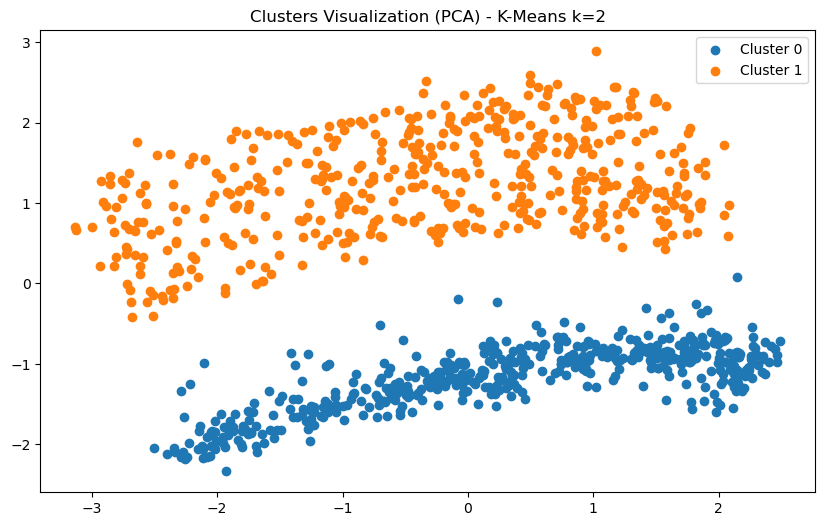

In [328]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_cluster)

plt.figure(figsize=(10, 6))
for cluster in range(2):
    mask = data['k_means_clusters'] == cluster
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1], label=f'Cluster {cluster}')
plt.title('Clusters Visualization (PCA) - K-Means k=2')
plt.legend()
plt.show()

<p style="color:#6c63ff; font-size:15px;"> Self Organizing Map </p>

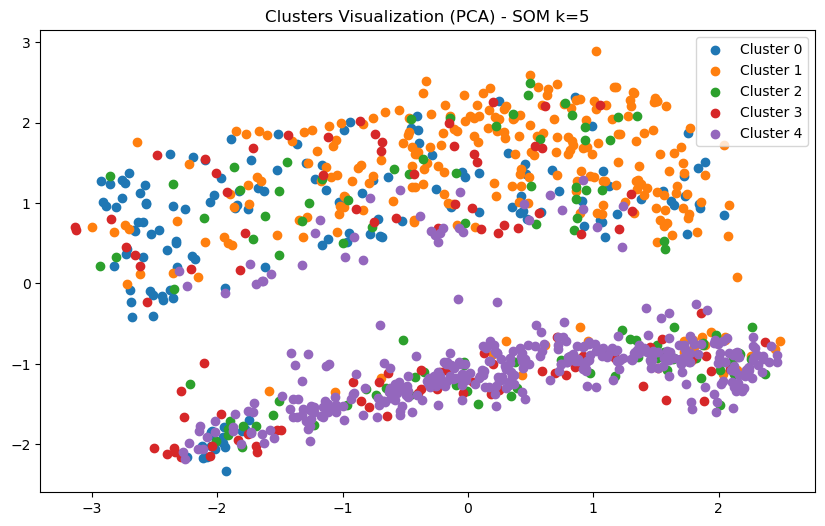

In [329]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_array)

plt.figure(figsize=(10, 6))
for cluster in np.unique(labels):
    mask = data['som_clusters'] == cluster
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1], label=f'Cluster {cluster}')
plt.title('Clusters Visualization (PCA) - SOM k=5')
plt.legend()
plt.show()

<h2 id = "imports" style="color:#6c63ff; border-bottom:2px solid #6c63ff; padding-bottom:5px;">9. Conclusions </h2>

<h3 id = "fisuma" style="color:#6c63ff; padding-bottom:5px;"> Summary of Findings</h3>

<p style="color:#6c63ff ; font-size:15px; line-height:1.7; margin:5px 0 15px;">Although Hierarchical Clustering achieved the highest silhouette score overall, the PCA visualization revealed that it suffered from the chaining effect, producing one dominant cluster and several tiny ones. K-Means, on the other hand, demonstrated a much clearer and more balanced separation of the data, cleanly identifying the 2 natural groups present in the dataset. Therefore, despite the lower silhouette score, K-Means was selected as the final model due to its superior cluster quality and interpretability.</p>

<h3 id = "bureco" style="color:#6c63ff; padding-bottom:5px;"> Business Recomendations</h3>

In [330]:
original_data = pd.read_csv('gym_membership.csv')

original_data["clusters"] = data['k_means_clusters']

original_data.groupby('clusters').mean(numeric_only=True).drop(columns=['id']).T

clusters,0,1
Age,30.633721,30.572314
visit_per_week,2.664729,2.700413
attend_group_lesson,0.036822,1.000000
avg_time_in_gym,104.655039,105.904959
drink_abo,0.500000,0.491736
personal_training,0.521318,0.514463
uses_sauna,0.474806,0.512397


<p style="color:#6c63ff; font-size:15px; line-height:1.7; margin:5px 0 15px;">
The cluster profiling revealed that the two clusters are very similar across most features, 
including age (~30 years), visits per week (~2.7), average time in gym (~105 minutes), 
drink consumption (~0.5), personal training (~0.52) and sauna usage (~0.50). 
The only significant difference lies in group lesson attendance, where Cluster 0 barely 
attends group lessons (0.037) while Cluster 1 attends them consistently (1.0).
Based on this, two business recommendations can be made:
<br><br>
- <strong>Invest in group lesson diversity</strong> — since a large portion of gym goers (Cluster 0) 
do not attend group lessons, offering a wider variety of classes such as calisthenics, 
strength training or hypertrophy-focused sessions could attract this segment.
<br><br>
- <strong>Retain and reward Cluster 1</strong> — gym goers who consistently attend group lessons 
are highly engaged and should be retained through loyalty programs, early access to 
new classes or exclusive scheduling.
</p>